# Organization Emotion Profiles - Phase 2

Building daily emotion time-series for organizations to detect perception shifts

## Step 1: Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from tqdm.auto import tqdm
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU'}")

OUTPUT_DIR = Path('results/phase_iii')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/home/le/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: GPU


In [6]:
print("Loading Stage 1 classification results...")

# ============================================================
# 1. Stage 1 classifications (article-level)
# ============================================================
classified = pd.read_parquet(
    'results/full_dataset_classification/full_dataset_labeled.parquet'
)
print(f"Stage 1 classified input: {len(classified):,} articles")

# ============================================================
# 2. Canonical cleaned entity mapping (article -> many companies)
# ============================================================
entity_matches = pd.read_parquet(
    'data/01_preprocessed/entity_matches_cleaned.parquet'
)

article_company_map = (
    entity_matches[['article_id', 'ticker', 'company_name']]
    .dropna(subset=['article_id', 'ticker'])
    .groupby(['article_id', 'ticker'], as_index=False)
    .agg(company_name=('company_name', 'first'))
)

print(
    f"Canonical cleaned corpus: "
    f"{article_company_map['article_id'].nunique():,} articles"
)
print(
    f"Article-company links: "
    f"{len(article_company_map):,}"
)

# ============================================================
# 3. Restrict Stage 1 to canonical cleaned corpus (article-level)
# ============================================================
canonical_ids = set(article_company_map['article_id'])

classified_stage2 = classified[
    classified['article_id'].isin(canonical_ids)
].copy()

print(
    f"Event-classified articles entering Stage 2: "
    f"{classified_stage2['article_id'].nunique():,}"
)
print(
    f"Stage 1 records outside final cleaned corpus: "
    f"{len(classified) - len(classified_stage2):,}"
)

# ============================================================
# 4. Reconstruct article text (article-level)
# ============================================================
sentences = pd.read_parquet(
    'data/01_preprocessed/sentences_entity_linked_cleaned.parquet'
)

sentences_stage2 = sentences[
    sentences['article_id'].isin(canonical_ids)
].copy()

articles_text = (
    sentences_stage2
    .groupby('article_id')
    .agg({
        'text': lambda x: ' '.join(x),
        'published_date': 'first'
    })
    .reset_index()
)

# ============================================================
# 5. Build unique article table (for emotion model)
# ============================================================
stage2_articles = classified_stage2.merge(
    articles_text[['article_id', 'text', 'published_date']],
    on='article_id',
    how='inner',
    validate='one_to_one'
)

stage2_articles['date'] = pd.to_datetime(stage2_articles['published_date'])

for cat in [
    'Communication', 'Governance', 'IT/Data',
    'Legal', 'Personnel', 'Processes', 'Products'
]:
    stage2_articles[f'{cat}_score'] = stage2_articles[cat]

stage2_articles['similarity_score'] = stage2_articles['top_score']

# ============================================================
# 6. Expand to article-company mentions (for company analysis)
# ============================================================
articles_df = stage2_articles.merge(
    article_company_map,
    on='article_id',
    how='inner',
    validate='one_to_many'
)

assert stage2_articles['article_id'].is_unique
assert articles_df[['article_id', 'ticker']].drop_duplicates().shape[0] == len(articles_df)
assert articles_df['ticker'].notna().all()

print(
    f"\nStage 2 article base: {len(stage2_articles):,} unique articles"
)
print(
    f"Stage 2 mention-level base: {len(articles_df):,} article-company rows"
)
print(
    f"Companies covered: {articles_df['ticker'].nunique():,}"
)
print(
    f"Avg companies mentioned per article: "
    f"{len(articles_df) / stage2_articles['article_id'].nunique():.2f}"
)

articles_df.head()

Loading Stage 1 classification results...
Stage 1 classified input: 19,031 articles
Canonical cleaned corpus: 19,556 articles
Article-company links: 23,509
Event-classified articles entering Stage 2: 18,928
Stage 1 records outside final cleaned corpus: 103

Stage 2 article base: 18,928 unique articles
Stage 2 mention-level base: 22,738 article-company rows
Companies covered: 737
Avg companies mentioned per article: 1.20


,article_id,predicted_category,is_ambiguous,ambiguous_categories,top_score,second_score,score_delta,Communication,Governance,IT/Data,...,Communication_score,Governance_score,IT/Data_score,Legal_score,Personnel_score,Processes_score,Products_score,similarity_score,ticker,company_name
0,99458.0,Legal,False,None,0.464661,0.451031,0.013630,0.424785,0.451031,0.434431,...,0.424785,0.451031,0.434431,0.464661,0.445130,0.424369,0.424207,0.464661,DBK,DEUTSCHE BANK AG
1,99570.0,Legal,False,None,0.530908,0.433850,0.097058,0.430794,0.433850,0.427056,...,0.430794,0.433850,0.427056,0.530908,0.430598,0.417240,0.404081,0.530908,G,ASSICURAZIONI GENERALI
2,99589.0,IT/Data,True,"Processes, IT/Data",0.490295,0.483428,0.006867,0.458752,0.467371,0.483428,...,0.458752,0.467371,0.483428,0.457592,0.465075,0.490295,0.465243,0.490295,DBK,DEUTSCHE BANK AG
3,99724.0,Processes,False,None,0.527982,0.492699,0.035283,0.481659,0.471244,0.473220,...,0.481659,0.471244,0.473220,0.475844,0.492699,0.527982,0.459482,0.527982,DBK,DEUTSCHE BANK AG
4,99740.0,IT/Data,False,None,0.457457,0.440612,0.016845,0.437012,0.440612,0.457457,...,0.437012,0.440612,0.457457,0.427413,0.435601,0.428995,0.402452,0.457457,VZ,VERIZON COMMUNICATIONS INC


## Step 2: Calculate Emotional Profiles

In [7]:
CACHE = OUTPUT_DIR / 'article_emotions_cache_v2.parquet'

EMOTIONS = [
    'anger',
    'fear',
    'sadness',
    'disgust',
    'joy',
    'neutral',
    'surprise'
]

# ============================================================
# Load or calculate article-level emotion probabilities
# ============================================================

# ...existing code...
if CACHE.exists():
    print("Loading cached emotions...")
    emotions = pd.read_parquet(CACHE)
else:
    print("Classifying emotions...")
    classifier = pipeline(
        "text-classification",
        model="j-hartmann/emotion-english-distilroberta-base",
        return_all_scores=True,
        device=device
    )

    batch_size = 256 if device == 0 else 32
    results = []

    for i in tqdm(range(0, len(stage2_articles), batch_size)):
        batch = stage2_articles['text'].iloc[i:i + batch_size].tolist()
        results.extend(
            classifier(batch, truncation=True, max_length=512)
        )

    emotion_data = []
    for aid, emos in zip(stage2_articles['article_id'], results):
        row = {'article_id': aid}
        for e in emos:
            row[e['label']] = e['score']
        row['dominant_emotion'] = max(emos, key=lambda x: x['score'])['label']
        emotion_data.append(row)

    emotions = pd.DataFrame(emotion_data)
    emotions.to_parquet(CACHE, index=False)

current_ids = set(stage2_articles['article_id'].astype(int))
emotion_ids = set(emotions['article_id'].astype(int))
assert current_ids == emotion_ids, "Emotion cache mismatch with current Stage 2 articles"
assert emotions['article_id'].is_unique

EMOTIONS = ['anger', 'fear', 'sadness', 'disgust', 'joy', 'neutral', 'surprise']
emotion_columns = EMOTIONS + ['dominant_emotion']

# add emotions to unique article table
stage2_articles = stage2_articles.drop(columns=[c for c in emotion_columns if c in stage2_articles.columns], errors='ignore')
stage2_articles = stage2_articles.merge(emotions, on='article_id', how='left', validate='one_to_one')

# add emotions to mention-level table used downstream
n_before = len(articles_df)
articles_df = articles_df.drop(columns=[c for c in emotion_columns if c in articles_df.columns], errors='ignore')
articles_df = articles_df.merge(
    stage2_articles[['article_id'] + emotion_columns],
    on='article_id',
    how='left',
    validate='many_to_one'
)
assert len(articles_df) == n_before
assert articles_df['dominant_emotion'].notna().all()

for emotion in EMOTIONS:
    assert articles_df[emotion].notna().all()


print("\nEmotion distribution:")
print(
    articles_df['dominant_emotion']
    .value_counts()
)

Loading cached emotions...

Emotion distribution:
dominant_emotion
neutral     12298
sadness      2804
anger        2725
fear         2374
disgust      1117
joy           983
surprise      437
Name: count, dtype: int64


In [8]:
print("Aggregating to observation-based organization level...")

articles_df['date_only'] = articles_df['date'].dt.date
daily = articles_df.groupby(['ticker', 'date_only']).agg(
    {**{'article_id': 'count'}, **{e: 'mean' for e in EMOTIONS}}
).reset_index()

daily.rename(columns={'article_id': 'article_count', 'date_only': 'date'}, inplace=True)
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['ticker', 'date']).reset_index(drop=True)

OUT = OUTPUT_DIR / 'organization_daily_emotions_v2.parquet'
daily.to_parquet(OUT, index=False)

print(f"{len(daily):,} company-days, saved to {OUT}")
daily.head()

Aggregating to observation-based organization level...
21,345 company-days, saved to results/phase_iii/organization_daily_emotions_v2.parquet


,ticker,date,article_count,anger,fear,sadness,disgust,joy,neutral,surprise
0,1,2022-08-08,1,0.025609,0.017434,0.005629,0.020358,0.407208,0.496626,0.027136
1,1038,2018-02-19,1,0.109426,0.093153,0.029876,0.716914,0.000765,0.043736,0.006130
2,11,2018-03-15,1,0.042659,0.034147,0.030695,0.361125,0.010508,0.499419,0.021447
3,12,2009-09-16,1,0.400484,0.552270,0.018280,0.007715,0.002951,0.015375,0.002925
4,12,2016-10-03,1,0.058844,0.050753,0.075063,0.014341,0.308184,0.323689,0.169126


In [9]:
print("Calculating 10-day successive observations...") # following De Bruyne et al. (2024)

results = []
for ticker in tqdm(daily['ticker'].unique()):
    cdf = daily[daily['ticker'] == ticker].sort_values('date').copy()
    
    for emotion in EMOTIONS:
        rm = cdf[emotion].rolling(10, min_periods=1).mean()
        rs = cdf[emotion].rolling(10, min_periods=1).std()
        cdf[f'{emotion}_z'] = np.where((rs > 0) & (~np.isnan(rs)), (cdf[emotion] - rm) / rs, 0)
    
    results.append(cdf)

daily_with_z = pd.concat(results, ignore_index=True)

print("\nZ-score stats (anger, sadness, fear, disgust):")
for e in ['anger', 'sadness', 'fear', 'disgust']:
    z = daily_with_z[f'{e}_z']
    print(f"  {e}: max={z.max():.1f}, z>2: {(z>2).sum():,} ({(z>2).mean()*100:.1f}%), z>3: {(z>3).sum():,}")

Calculating 10-day successive observations...


  0%|          | 0/737 [00:00<?, ?it/s]

100%|██████████| 737/737 [00:05<00:00, 134.88it/s]



Z-score stats (anger, sadness, fear, disgust):
  anger: max=2.8, z>2: 1,395 (6.5%), z>3: 0
  sadness: max=2.8, z>2: 1,295 (6.1%), z>3: 0
  fear: max=2.8, z>2: 1,497 (7.0%), z>3: 0
  disgust: max=2.8, z>2: 1,451 (6.8%), z>3: 0


## Step 3: Detect Peaks

* Using four negative emotions (anger, sadness, fear, disgust) for peak detection
* Threshold sensitivity analysis is first conducted to find optimal sensitivity

In [10]:
# Test different threshold combinations to find optimal sensitivity
print("Testing different peak detection thresholds...")
print("="*80)

EMOTION_COLS = ['anger', 'sadness', 'fear', 'disgust']

def detect_peaks(df, z_threshold, min_days, emotion_cols=EMOTION_COLS):
    """
    Detect sustained emotion peaks with configurable thresholds.
    Returns a DataFrame with per-emotion max/mean z-scores, dominant emotion,
    and summary fields needed for both the sensitivity sweep and downstream analysis.
    """
    peaks = []
    for ticker in df['ticker'].unique():
        cdf = df[df['ticker'] == ticker].sort_values('date').copy()

        cdf['is_elevated'] = False
        for emotion in emotion_cols:
            cdf['is_elevated'] |= (cdf[f'{emotion}_z'] > z_threshold)

        cdf['period_id'] = (cdf['is_elevated'] != cdf['is_elevated'].shift()).cumsum()

        for period_id, period_df in cdf.groupby('period_id'):
            if period_df['is_elevated'].iloc[0] and len(period_df) >= min_days:
                emotion_means = {e: period_df[f'{e}_z'].mean() for e in emotion_cols}
                dominant_emotion = max(emotion_means, key=emotion_means.get)

                peaks.append({
                    'peak_id':          f"{ticker}_{period_df['date'].min().strftime('%Y%m%d')}",
                    'ticker':           ticker,
                    'start_date':       period_df['date'].min(),
                    'end_date':         period_df['date'].max(),
                    'duration_days':    len(period_df),
                    'max_anger_z':      period_df['anger_z'].max(),
                    'max_sadness_z':    period_df['sadness_z'].max(),
                    'max_fear_z':       period_df['fear_z'].max(),
                    'max_disgust_z':    period_df['disgust_z'].max(),
                    'mean_anger_z':     emotion_means['anger'],
                    'mean_sadness_z':   emotion_means['sadness'],
                    'mean_fear_z':      emotion_means['fear'],
                    'mean_disgust_z':   emotion_means['disgust'],
                    'max_z':            max(period_df[f'{e}_z'].max() for e in emotion_cols),
                    'dominant_emotion': dominant_emotion,
                    'total_articles':   period_df['article_count'].sum()
                })
    return pd.DataFrame(peaks)

# Sweep: z-thresholds × min duration
z_thresholds  = [1.5, 1.8, 2.0, 2.5, 3]
min_durations = [2, 3, 4, 5, 6, 7, 8, 10]
high_profile  = ['GOOG', 'AMZN', 'META', 'TSLA', 'SHEL']

results_summary = []

for z_thresh in z_thresholds:
    for min_dur in min_durations:
        peaks_df = detect_peaks(daily_with_z, z_thresh, min_dur)

        unique_companies = peaks_df['ticker'].nunique() if len(peaks_df) > 0 else 0
        hp_with_peaks = 0
        hp_peak_count = 0
        if len(peaks_df) > 0:
            for ticker in high_profile:
                company_peaks = peaks_df[peaks_df['ticker'] == ticker]
                if len(company_peaks) > 0:
                    hp_with_peaks += 1
                    hp_peak_count += len(company_peaks)

        results_summary.append({
            'z_threshold':          z_thresh,
            'min_days':             min_dur,
            'total_peaks':          len(peaks_df),
            'companies_affected':   unique_companies,
            'avg_duration':         peaks_df['duration_days'].mean() if len(peaks_df) > 0 else 0,
            'max_duration':         peaks_df['duration_days'].max() if len(peaks_df) > 0 else 0,
            'high_profile_companies': hp_with_peaks,
            'high_profile_peaks':   hp_peak_count
        })

results_summary_df = pd.DataFrame(results_summary)

print("\nTHRESHOLD SENSITIVITY ANALYSIS")
print("="*80)
print(results_summary_df.to_string(index=False))

Testing different peak detection thresholds...

THRESHOLD SENSITIVITY ANALYSIS
 z_threshold  min_days  total_peaks  companies_affected  avg_duration  max_duration  high_profile_companies  high_profile_peaks
         1.5         2         1774                 270      2.612176            10                       5                 386
         1.5         3          662                 194      3.640483            10                       5                 140
         1.5         4          261                 119      4.624521            10                       5                  47
         1.5         5          103                  62      5.582524            10                       5                  20
         1.5         6           38                  30      6.578947            10                       4                   9
         1.5         7           15                  13      7.466667            10                       2                   4
         1.5         8   

In [11]:
# Save results summary
results_summary_df.to_csv(OUTPUT_DIR / 'peak_detection_sensitivity_summary.csv', index=False)

✓ Visualization saved: results/phase_iii/threshold_sensitivity_analysis.png


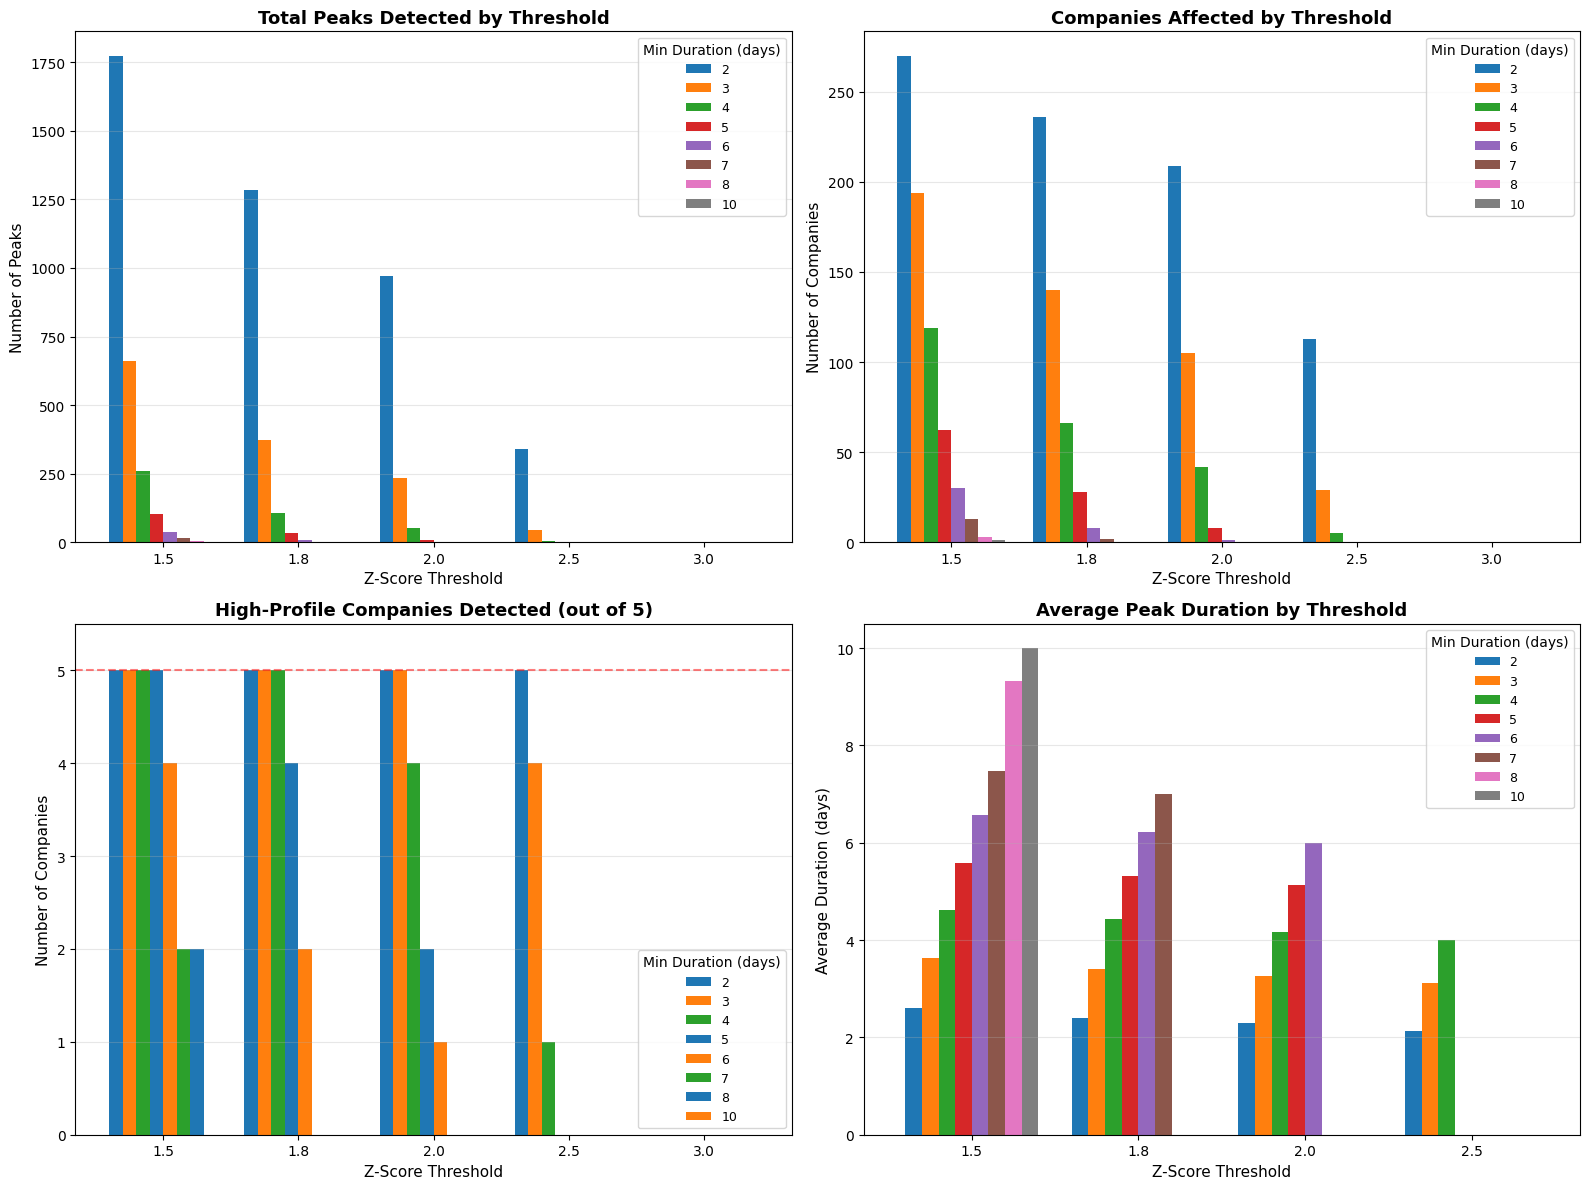

In [12]:
# Visualize threshold sensitivity
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total peaks by threshold
ax1 = axes[0, 0]
pivot_total = results_summary_df.pivot(index='z_threshold', columns='min_days', values='total_peaks')
pivot_total.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Total Peaks Detected by Threshold', fontsize=13, fontweight='bold')
ax1.set_xlabel('Z-Score Threshold', fontsize=11)
ax1.set_ylabel('Number of Peaks', fontsize=11)
ax1.legend(title='Min Duration (days)', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# 2. Companies affected by threshold
ax2 = axes[0, 1]
pivot_companies = results_summary_df.pivot(index='z_threshold', columns='min_days', values='companies_affected')
pivot_companies.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Companies Affected by Threshold', fontsize=13, fontweight='bold')
ax2.set_xlabel('Z-Score Threshold', fontsize=11)
ax2.set_ylabel('Number of Companies', fontsize=11)
ax2.legend(title='Min Duration (days)', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# 3. High-profile company coverage
ax3 = axes[1, 0]
pivot_hp = results_summary_df.pivot(index='z_threshold', columns='min_days', values='high_profile_companies')
pivot_hp.plot(kind='bar', ax=ax3, width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax3.set_title('High-Profile Companies Detected (out of 5)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Z-Score Threshold', fontsize=11)
ax3.set_ylabel('Number of Companies', fontsize=11)
ax3.legend(title='Min Duration (days)', fontsize=9)
ax3.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='All 5 detected')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.set_ylim(0, 5.5)

# 4. Average peak duration
ax4 = axes[1, 1]
pivot_duration = results_summary_df[results_summary_df['avg_duration'] > 0].pivot(index='z_threshold', columns='min_days', values='avg_duration')
pivot_duration.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Average Peak Duration by Threshold', fontsize=13, fontweight='bold')
ax4.set_xlabel('Z-Score Threshold', fontsize=11)
ax4.set_ylabel('Average Duration (days)', fontsize=11)
ax4.legend(title='Min Duration (days)', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('results/phase_iii/threshold_sensitivity_analysis.png', dpi=200, bbox_inches='tight')
print("✓ Visualization saved: results/phase_iii/threshold_sensitivity_analysis.png")
plt.show()

## Step 4: Apply Chosen Threshold

In [13]:
# ── Apply chosen threshold ────────────────────────────────────────────────────
LOOSE_Z_THRESHOLD = 1.5
LOOSE_MIN_DAYS    = 2

print("="*80)
print(f"Step 4: Applying chosen threshold (z>{LOOSE_Z_THRESHOLD}, {LOOSE_MIN_DAYS}+ days)")
print("="*80)

loose_peaks = detect_peaks(daily_with_z, z_threshold=LOOSE_Z_THRESHOLD, min_days=LOOSE_MIN_DAYS)

# Add company metadata
company_metadata = articles_df.groupby('ticker').agg(
    company_name=('company_name', 'first'),
    total_articles_in_dataset=('article_id', 'count')
).reset_index()

loose_peaks = loose_peaks.merge(company_metadata, on='ticker', how='left')

print(f"✓ Detected {len(loose_peaks):,} peaks across {loose_peaks['ticker'].nunique()} companies")
print(f"  Date range: {loose_peaks['start_date'].min().date()} to {loose_peaks['end_date'].max().date()}")

# ── Category evolution ────────────────────────────────────────────────────────
# Category columns exist on articles_df with _score suffix (added in Step 2).
# Define explicitly — do NOT infer from full_dataset_labeled.parquet which uses bare names.
CATEGORIES = ['Communication', 'Governance', 'IT/Data', 'Legal', 'Personnel', 'Processes', 'Products']
category_score_cols = [f'{cat}_score' for cat in CATEGORIES]

def get_peak_category_evolution(peak_row, articles_df):
    """Get weighted category proportion evolution across all days of a peak."""
    ticker     = peak_row['ticker']
    start_date = pd.to_datetime(peak_row['start_date']).date()
    end_date   = pd.to_datetime(peak_row['end_date']).date()

    peak_articles = articles_df[
        (articles_df['ticker']    == ticker) &
        (articles_df['date_only'] >= start_date) &
        (articles_df['date_only'] <= end_date)
    ][['article_id', 'date_only'] + category_score_cols]

    evolution = []
    for date in pd.date_range(start_date, end_date):
        date_only    = date.date()
        date_articles = peak_articles[peak_articles['date_only'] == date_only]
        if len(date_articles) > 0:
            category_scores = {cat: date_articles[f'{cat}_score'].mean() for cat in CATEGORIES}
            total_score     = sum(category_scores.values())
            category_props  = {
                cat: score / total_score if total_score > 0 else 0
                for cat, score in category_scores.items()
            }
            evolution.append({
                'date':          date,
                'day_offset':    (date_only - start_date).days,
                'article_count': len(date_articles),
                **category_props
            })

    return pd.DataFrame(evolution)

def get_primary_category(evolution_records):
    if not evolution_records:
        return None
    df = pd.DataFrame(evolution_records)
    category_means = {cat: df[cat].mean() for cat in CATEGORIES if cat in df.columns}
    return max(category_means, key=category_means.get) if category_means else None

print(f"\n  Extracting category evolution for {len(loose_peaks):,} peaks...")

loose_peaks['category_evolution'] = None
for idx, peak in tqdm(loose_peaks.iterrows(), total=len(loose_peaks), desc="  Processing peaks"):
    evolution = get_peak_category_evolution(peak, articles_df)
    loose_peaks.at[idx, 'category_evolution'] = evolution.to_dict('records')

loose_peaks['primary_category'] = loose_peaks['category_evolution'].apply(get_primary_category)

print(f"\n  Primary category distribution:")
print(loose_peaks['primary_category'].value_counts())
print(f"  Missing (no articles in window): {loose_peaks['primary_category'].isna().sum()}")

Step 4: Applying chosen threshold (z>1.5, 2+ days)
✓ Detected 1,774 peaks across 270 companies
  Date range: 2008-02-15 to 2024-12-24

  Extracting category evolution for 1,774 peaks...


  Processing peaks: 100%|██████████| 1774/1774 [00:46<00:00, 37.89it/s] 



  Primary category distribution:
primary_category
Communication    718
Governance       364
Legal            235
IT/Data          128
Processes        117
Personnel        115
Products          97
Name: count, dtype: int64
  Missing (no articles in window): 0


## Step 5: Profile Emotion-Event Patterns

In [14]:
print("Step 5: Profiling emotion-event patterns...")

# We apply the results from previous steps to profile the detected peaks, analyzing their dominant emotions, primary categories, intensity distributions, and durations. This will help us understand the characteristics of these emotion events and their potential implications for companies.
all_peaks = loose_peaks.copy()

# Dominant emotion distribution
print("\n5.1 Dominant Emotion Distribution:")
print(all_peaks['dominant_emotion'].value_counts())

# Primary category distribution by emotion
print("\n5.2 Primary Category by Dominant Emotion:")
category_emotion_crosstab = pd.crosstab(
    all_peaks['primary_category'],
    all_peaks['dominant_emotion'],
    margins=True
)
print(category_emotion_crosstab.sort_values('All', ascending=False).head(15))

# Intensity statistics
print("\n5.3 Intensity Statistics:")
for emo in ['anger', 'sadness', 'fear', 'disgust']:
    print(f"\n{emo.capitalize()} max z-score distribution:")
    print(all_peaks[f'max_{emo}_z'].describe())

# Duration distribution
print("\n5.4 Duration Distribution:")
print(all_peaks['duration_days'].describe())
print(f"  Longest peak: {all_peaks['duration_days'].max()} days")
print(f"  Multi-day events: {len(all_peaks[all_peaks['duration_days'] > 1])}")

print(f"\n✓ Profiling complete")
print(f"  Total peaks cataloged: {len(all_peaks):,}")
print(f"  Companies affected: {all_peaks['ticker'].nunique()}")

Step 5: Profiling emotion-event patterns...

5.1 Dominant Emotion Distribution:
dominant_emotion
fear       492
anger      444
sadness    429
disgust    409
Name: count, dtype: int64

5.2 Primary Category by Dominant Emotion:
dominant_emotion  anger  disgust  fear  sadness   All
primary_category                                     
All                 444      409   492      429  1774
Communication       180      157   193      188   718
Governance           74       96   112       82   364
Legal                96       47    50       42   235
IT/Data              33       35    38       22   128
Processes            21       21    39       36   117
Personnel            26       33    26       30   115
Products             14       20    34       29    97

5.3 Intensity Statistics:

Anger max z-score distribution:
count    1774.000000
mean        1.436095
std         1.154161
min        -1.069964
25%         0.288687
50%         1.784601
75%         2.448893
max         2.845328
Name: 

Visualization saved: results/phase_iii/loose_threshold_summary.png


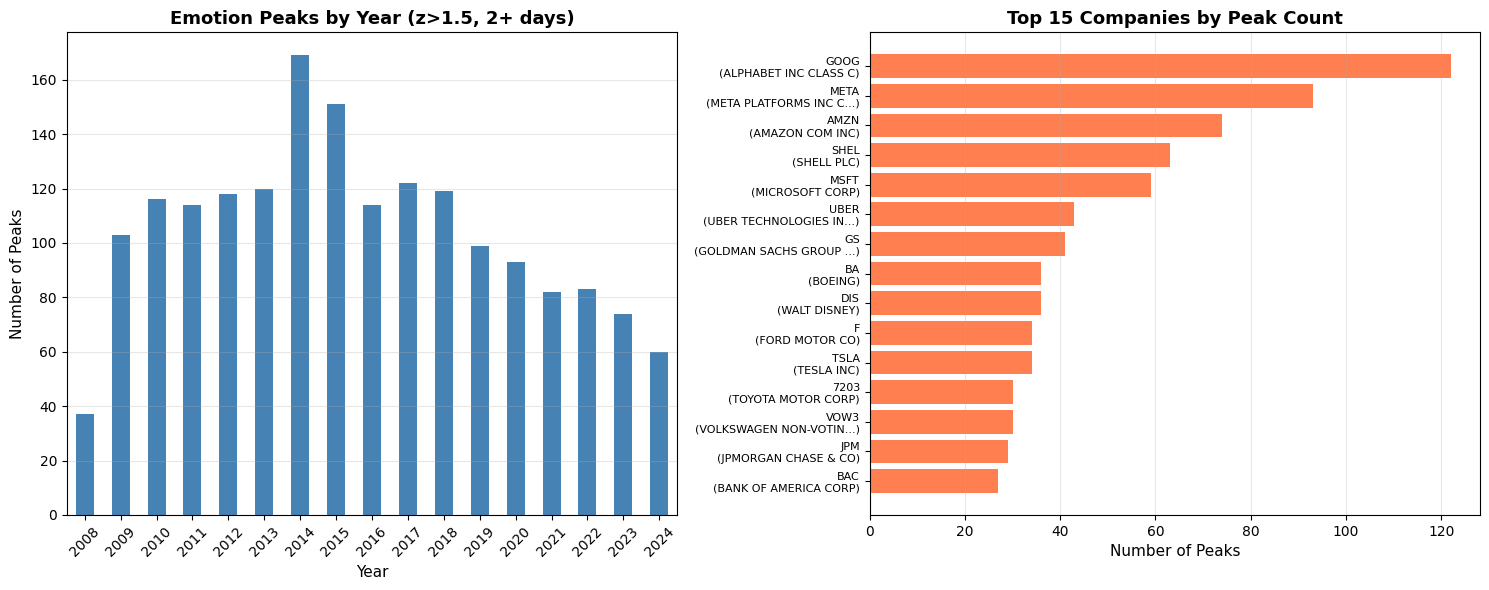

In [15]:
# Visualize loose threshold results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Peaks over time
ax1 = axes[0]
peaks_by_year = loose_peaks.groupby(loose_peaks['start_date'].dt.year).size()
peaks_by_year.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Emotion Peaks by Year (z>1.5, 2+ days)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Number of Peaks', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# 2. Top 15 companies by peak count
ax2 = axes[1]
top_companies = loose_peaks.groupby('ticker').size().nlargest(15)
top_companies_with_names = []
for ticker in top_companies.index:
    name = loose_peaks[loose_peaks['ticker'] == ticker]['company_name'].iloc[0]
    label = f"{ticker}\n({name[:20]}...)" if len(name) > 20 else f"{ticker}\n({name})"
    top_companies_with_names.append(label)

ax2.barh(range(len(top_companies)), top_companies.values, color='coral')
ax2.set_yticks(range(len(top_companies)))
ax2.set_yticklabels(top_companies_with_names, fontsize=8)
ax2.set_title('Top 15 Companies by Peak Count', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Peaks', fontsize=11)
ax2.grid(True, alpha=0.3, axis='x')
ax2.invert_yaxis()


plt.tight_layout()
plt.savefig('results/phase_iii/loose_threshold_summary.png', dpi=200, bbox_inches='tight')
print("Visualization saved: results/phase_iii/loose_threshold_summary.png")
plt.show()

In [16]:
# Summary statistics for loose threshold
print("="*80)
print("LOOSE THRESHOLD DETECTION SUMMARY (z>1.5, 2+ days)")
print("="*80)

print(f"\nOVERALL STATISTICS:")
print(f"   Total peaks detected: {len(loose_peaks):,}")
print(f"   Companies affected: {loose_peaks['ticker'].nunique()}")
print(f"   Coverage: {loose_peaks['ticker'].nunique() / articles_df['ticker'].nunique() * 100:.1f}% of companies in dataset")
print(f"   Date range: {loose_peaks['start_date'].min().year} - {loose_peaks['end_date'].max().year}")


print(f"\nEMOTION DISTRIBUTION:")
for emotion in ['anger', 'sadness', 'fear', 'disgust']:
    count = (loose_peaks['dominant_emotion'] == emotion).sum()
    pct = count / len(loose_peaks) * 100
    print(f"   {emotion.capitalize():8s}: {count:3d} peaks ({pct:5.1f}%)")

print(f"\nDURATION STATISTICS:")
print(f"   Mean: {loose_peaks['duration_days'].mean():.2f} days")
print(f"   Median: {loose_peaks['duration_days'].median():.0f} days")
print(f"   Max: {loose_peaks['duration_days'].max():.0f} days")
print(f"   2-day peaks: {(loose_peaks['duration_days'] == 2).sum()} ({(loose_peaks['duration_days'] == 2).sum() / len(loose_peaks) * 100:.1f}%)")
print(f"   3+ day peaks: {(loose_peaks['duration_days'] >= 3).sum()} ({(loose_peaks['duration_days'] >= 3).sum() / len(loose_peaks) * 100:.1f}%)")

print(f"\nTEMPORAL PATTERNS:")
peak_years = loose_peaks['start_date'].dt.year
print(f"   Peak year: {peak_years.mode().iloc[0]} ({peak_years.value_counts().max()} peaks)")
print(f"   Recent trend (2020-2024): {(peak_years >= 2020).sum()} peaks")

# Export final peaks dataset
OUT_PEAKS = OUTPUT_DIR / 'all_peaks_loose_threshold.parquet'
loose_peaks.to_parquet(OUT_PEAKS, index=False)
loose_peaks.to_csv(OUTPUT_DIR / 'all_peaks_loose_threshold.csv', index=False)

print("\nDataset exported to:")
print("  • results/phase_iii/all_peaks_loose_threshold.parquet")
print("  • results/phase_iii/all_peaks_loose_threshold.csv")
print("="*80)

LOOSE THRESHOLD DETECTION SUMMARY (z>1.5, 2+ days)

OVERALL STATISTICS:
   Total peaks detected: 1,774
   Companies affected: 270
   Coverage: 36.6% of companies in dataset
   Date range: 2008 - 2024

EMOTION DISTRIBUTION:
   Anger   : 444 peaks ( 25.0%)
   Sadness : 429 peaks ( 24.2%)
   Fear    : 492 peaks ( 27.7%)
   Disgust : 409 peaks ( 23.1%)

DURATION STATISTICS:
   Mean: 2.61 days
   Median: 2 days
   Max: 10 days
   2-day peaks: 1112 (62.7%)
   3+ day peaks: 662 (37.3%)

TEMPORAL PATTERNS:
   Peak year: 2014 (169 peaks)
   Recent trend (2020-2024): 392 peaks

Dataset exported to:
  • results/phase_iii/all_peaks_loose_threshold.parquet
  • results/phase_iii/all_peaks_loose_threshold.csv


## Prepare Validation Sample

This step performs one-time stratified sampling for manual validation review. The sampling itself is deterministic (seeded), but the exported CSV is meant to be hand-annotated afterwards (`is_real_crisis`, `crisis_description`, `notes`). The cell below now checks whether `validation_sample_peaks.csv` already exists and, if so, loads it instead of re-sampling -- so it is safe to include in a full top-to-bottom rerun without overwriting any manual annotations.

In [17]:
print("Step 6: Preparing validation sample...")

output_path = 'results/phase_iii/validation_sample_peaks.csv'

if Path(output_path).exists():
    # This file is meant to be hand-annotated after the initial sampling run
    # (is_real_crisis / crisis_description / notes filled in by a human reviewer).
    # Re-sampling here would silently regenerate a different set of peaks and
    # desync from that manual review, so on a rerun we just reload it instead.
    print(f"  Found existing validation sample at {output_path} -- loading it "
          f"instead of re-sampling (it may contain manual review annotations).")
    validation_export = pd.read_csv(output_path)
    print(f"  Loaded {len(validation_export)} peaks")
else:
    # Stratified sampling: 50 peaks
    # Stratify by dominant emotion and primary category

    np.random.seed(42)

    def stratified_sample(df, n_samples, strata_cols):
        """Sample ensuring representation across strata."""
        if len(df) == 0:
            return pd.DataFrame()

        samples = []

        # Calculate samples per stratum
        strata_counts = df.groupby(strata_cols).size()
        total = len(df)

        for stratum_key, count in strata_counts.items():
            stratum_df = df
            for col, val in zip(strata_cols, stratum_key if isinstance(stratum_key, tuple) else [stratum_key]):
                stratum_df = stratum_df[stratum_df[col] == val]

            # Proportional allocation with minimum 1 sample per stratum if possible
            target_n = max(1, int(n_samples * count / total))
            actual_n = min(target_n, len(stratum_df))

            if actual_n > 0:
                sample = stratum_df.sample(n=actual_n, random_state=42)
                samples.append(sample)

        if len(samples) == 0:
            return pd.DataFrame()

        result = pd.concat(samples, ignore_index=True)

        # If we're short, randomly sample more from the entire dataset
        if len(result) < n_samples:
            remaining = df[~df['peak_id'].isin(result['peak_id'])]
            if len(remaining) > 0:
                additional = remaining.sample(n=min(n_samples - len(result), len(remaining)), random_state=42)
                result = pd.concat([result, additional], ignore_index=True)

        # If we have too many, randomly drop
        if len(result) > n_samples:
            result = result.sample(n=n_samples, random_state=42)

        return result

    # Sample peaks without distinguishing between acute and sustained
    validation_sample = stratified_sample(all_peaks, n_samples=50, strata_cols=['dominant_emotion'])

    print(f"  Sampled {len(validation_sample)} peaks")

    # Add article text to validation sample
    print("  Adding article text...")
    validation_sample['start_date'] = pd.to_datetime(validation_sample['start_date']).dt.tz_localize('UTC')
    validation_sample['end_date'] = pd.to_datetime(validation_sample['end_date']).dt.tz_localize('UTC')
    validation_sample['article_texts'] = ''

    for idx, row in tqdm(validation_sample.iterrows(), total=len(validation_sample), desc="  Processing peaks"):
        ticker = row['ticker']
        start_date = row['start_date']
        end_date = row['end_date']

        # Find articles for this peak
        peak_articles = articles_df[
            (articles_df['ticker'] == ticker) &
            (articles_df['date'] >= start_date) &
            (articles_df['date'] <= end_date)
        ].sort_values('date')

        if len(peak_articles) > 0:
            # Concatenate all article texts with separators
            article_texts = []
            for _, article in peak_articles.iterrows():
                date_str = article['date'].strftime('%Y-%m-%d')
                article_texts.append(f"[{date_str}] {article['text'][:500]}...")  # Truncate each to 500 chars for readability

            validation_sample.at[idx, 'article_texts'] = '\n\n'.join(article_texts)
        else:
            validation_sample.at[idx, 'article_texts'] = '[No articles found]'

    # Prepare validation file with fields for manual review
    validation_export = validation_sample.copy()
    validation_export['is_real_crisis'] = ''
    validation_export['crisis_description'] = ''
    validation_export['notes'] = ''

    # Save
    validation_export.to_csv(output_path, index=False)

    print(f"\n✓ Validation sample saved: {output_path}")
    print(f"  Peaks with articles: {(validation_export['article_texts'] != '[No articles found]').sum()}/{len(validation_export)}")

# Also save full peak catalog (always refreshed -- these are derived outputs,
# not manually annotated, so it's safe to overwrite them on every run)
all_peaks_path = 'results/phase_iii/all_emotion_peaks.parquet'
all_peaks.to_parquet(all_peaks_path, index=False)

loose_peaks_path = 'results/phase_iii/loose_peaks.parquet'
loose_peaks.to_parquet(loose_peaks_path, index=False)

print(f"✓ Full peak catalog saved: {all_peaks_path}")
print(f"✓ Loose peaks saved: {loose_peaks_path}")

print("\n" + "="*60)
print("PHASE 2 ANALYSIS COMPLETE")
print("="*60)
print(f"\nSummary:")
print(f"  Total emotion peaks identified: {len(all_peaks):,}")
print(f"  Companies affected: {all_peaks['ticker'].nunique()}")
print(f"  Date range: {all_peaks['start_date'].min().date()} to {all_peaks['end_date'].max().date()}")
print(f"\nOutputs:")
print(f"  - {output_path}")
print(f"  - {all_peaks_path}")
print(f"  - {loose_peaks_path}")

Step 6: Preparing validation sample...
  Found existing validation sample at results/phase_iii/validation_sample_peaks.csv -- loading it instead of re-sampling (it may contain manual review annotations).
  Loaded 50 peaks
✓ Full peak catalog saved: results/phase_iii/all_emotion_peaks.parquet
✓ Loose peaks saved: results/phase_iii/loose_peaks.parquet

PHASE 2 ANALYSIS COMPLETE

Summary:
  Total emotion peaks identified: 1,774
  Companies affected: 270
  Date range: 2008-02-15 to 2024-12-24

Outputs:
  - results/phase_iii/validation_sample_peaks.csv
  - results/phase_iii/all_emotion_peaks.parquet
  - results/phase_iii/loose_peaks.parquet
